## Step 1: Load And Start

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"
df = pd.read_csv(url)

# First look
print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.dtypes}")
print(f"\nFirst 5 rows:\n{df.head()}")

Shape: (768, 9)

Columns:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3           

In [3]:
print("\nBasic Statistics:")
print(df.describe().round(2))

# Target distribution 
print("\nTarget Distribution:")
print(df["Outcome"].value_counts())
print(df["Outcome"].value_counts(normalize=True).round(2))


Basic Statistics:
       Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin     BMI  \
count       768.00   768.00         768.00         768.00   768.00  768.00   
mean          3.85   120.89          69.11          20.54    79.80   31.99   
std           3.37    31.97          19.36          15.95   115.24    7.88   
min           0.00     0.00           0.00           0.00     0.00    0.00   
25%           1.00    99.00          62.00           0.00     0.00   27.30   
50%           3.00   117.00          72.00          23.00    30.50   32.00   
75%           6.00   140.25          80.00          32.00   127.25   36.60   
max          17.00   199.00         122.00          99.00   846.00   67.10   

       DiabetesPedigreeFunction     Age  Outcome  
count                    768.00  768.00   768.00  
mean                       0.47   33.24     0.35  
std                        0.33   11.76     0.48  
min                        0.08   21.00     0.00  
25%                    

## Data Understanding Summary

### Dataset Overview
- **Rows:** 768  
- **Columns:** 9  
- **Target Variable:** `Outcome`
  - `0` → No Diabetes  
  - `1` → Diabetes  

### Data Types
- All features are **numerical** (`int64` / `float64`)
- No categorical columns
- No encoding required  

### Hidden Missing Values
Some columns contain `0` values that are unrealistic and represent missing data:
- Glucose  
- BloodPressure  
- SkinThickness  
- Insulin  
- BMI  

### Valid Zero Values
These columns can legitimately contain zero values:
- Pregnancies  
- DiabetesPedigreeFunction  
- Age  

### Target Distribution
- **Class 0:** 500 records (**65%**)  
- **Class 1:** 268 records (**35%**)  

### Conclusion
- Hidden missing values exist  
- Slight class imbalance exists  
- Next step: replace invalid zeros with `NaN` and handle missing values

## Step 2: Missing Values 

In [4]:
# Step 1: Replace zeros with NaN 
cols_with_hidden_missing = [
    "Glucose", "BloodPressure",
    "SkinThickness", "Insulin", "BMI"
]

df[cols_with_hidden_missing] = df[cols_with_hidden_missing].replace(0, np.nan)


In [5]:
# Step 2: Check missing values 
missing = pd.DataFrame({
    "Missing Count"  : df.isnull().sum(),
    "Missing Percent": (df.isnull().mean() * 100).round(2)
})

print("Missing Values After Replacing Zeros:")
print(missing[missing["Missing Count"] > 0])

Missing Values After Replacing Zeros:
               Missing Count  Missing Percent
Glucose                    5             0.65
BloodPressure             35             4.56
SkinThickness            227            29.56
Insulin                  374            48.70
BMI                       11             1.43


Missing %:
< 5%    → impute with mean/median        (very safe)
5–30%   → impute with median/group median (careful)
30–50%  → impute with median but flag it  (risky)
> 50%   → drop the column                (too much)

Insulin = 48.7% → borderline
→ We will impute BUT create a flag column
  to tell model "this value was missing"

### Apply Treatment

In [6]:
# Flag column for Insulin
# tells model which insulin values were imputed
df["Insulin_missing"] = df["Insulin"].isnull().astype(int)
df["SkinThickness_missing"] = df["SkinThickness"].isnull().astype(int)

print("Missing flags created:")
print(df[["Insulin_missing", "SkinThickness_missing"]].value_counts())

# Impute all with MEDIAN
# Median is better than mean for medical data
# because it is robust to outliers

for col in cols_with_hidden_missing:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)   
    print(f"  {col:20} filled with median = {median_val:.2f}")

# Verify
print(f"\nMissing values remaining: {df.isnull().sum().sum()}")

Missing flags created:
Insulin_missing  SkinThickness_missing
0                0                        394
1                1                        227
                 0                        147
Name: count, dtype: int64
  Glucose              filled with median = 117.00
  BloodPressure        filled with median = 72.00
  SkinThickness        filled with median = 29.00
  Insulin              filled with median = 125.00
  BMI                  filled with median = 32.30

Missing values remaining: 0


 Used MEDIAN (not mean) — robust to medical outliers
→ All missing values resolved 

## Step 3: Univariate Analysis

In [7]:
print("Distribution Summary:")
print(f"{'Column':28} {'Skew':>8} {'Kurt':>8} {'Status'}")
print("-" * 60)

cols = ["Pregnancies", "Glucose", "BloodPressure",
        "SkinThickness", "Insulin", "BMI",
        "DiabetesPedigreeFunction", "Age"]

for col in cols:
    skew = df[col].skew()
    kurt = df[col].kurt()
    if abs(skew) < 0.5:
        status = " Normal"
    elif abs(skew) < 1.0:
        status = " Moderate"
    else:
        status = " High Skew"
    print(f"{col:28} {skew:8.2f} {kurt:8.2f}  {status}")

Distribution Summary:
Column                           Skew     Kurt Status
------------------------------------------------------------
Pregnancies                      0.90     0.16   Moderate
Glucose                          0.54    -0.26   Moderate
BloodPressure                    0.14     1.10   Normal
SkinThickness                    0.84     5.43   Moderate
Insulin                          3.38    16.23   High Skew
BMI                              0.60     0.92   Moderate
DiabetesPedigreeFunction         1.92     5.59   High Skew
Age                              1.13     0.64   High Skew


### Histograms for All Columns

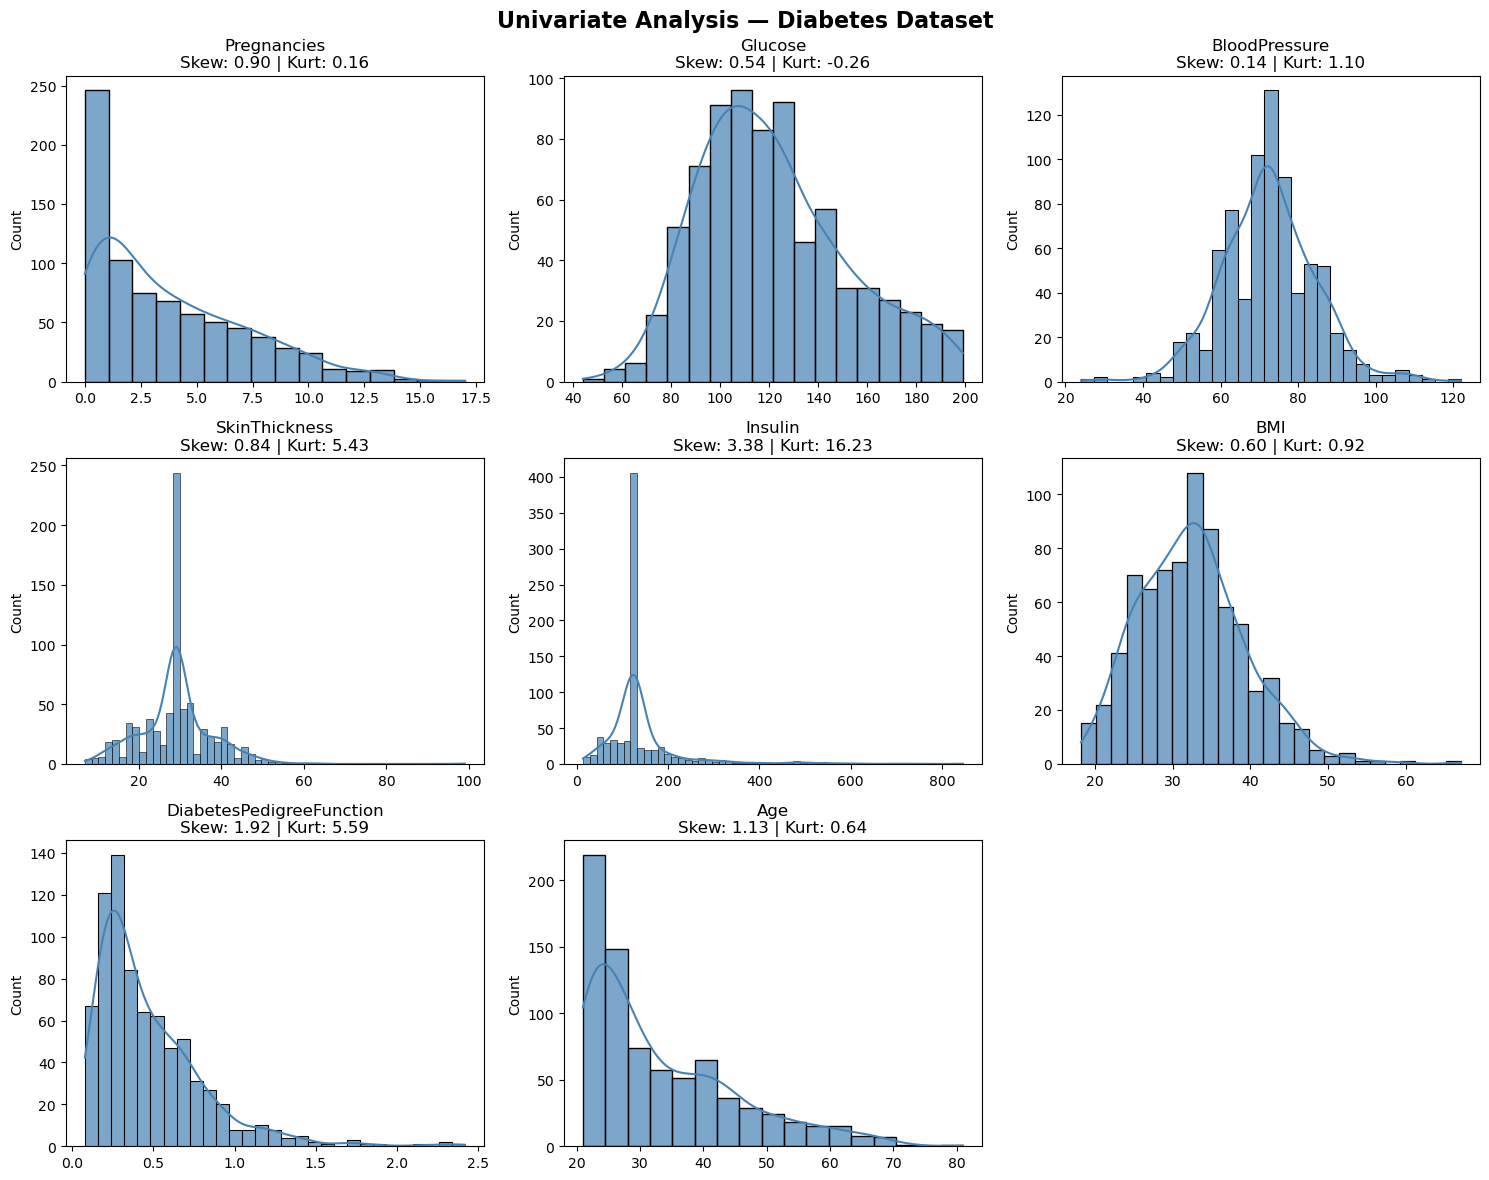

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(data=df, x=col, kde=True,
                 ax=axes[i], color="steelblue", alpha=0.7)
    axes[i].set_title(
        f"{col}\nSkew: {df[col].skew():.2f} | "
        f"Kurt: {df[col].kurt():.2f}"
    )
    axes[i].set_xlabel("")

# Hide last empty subplot
axes[-1].set_visible(False)

plt.suptitle("Univariate Analysis — Diabetes Dataset",
             fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

### Boxplots — Spot Outliers

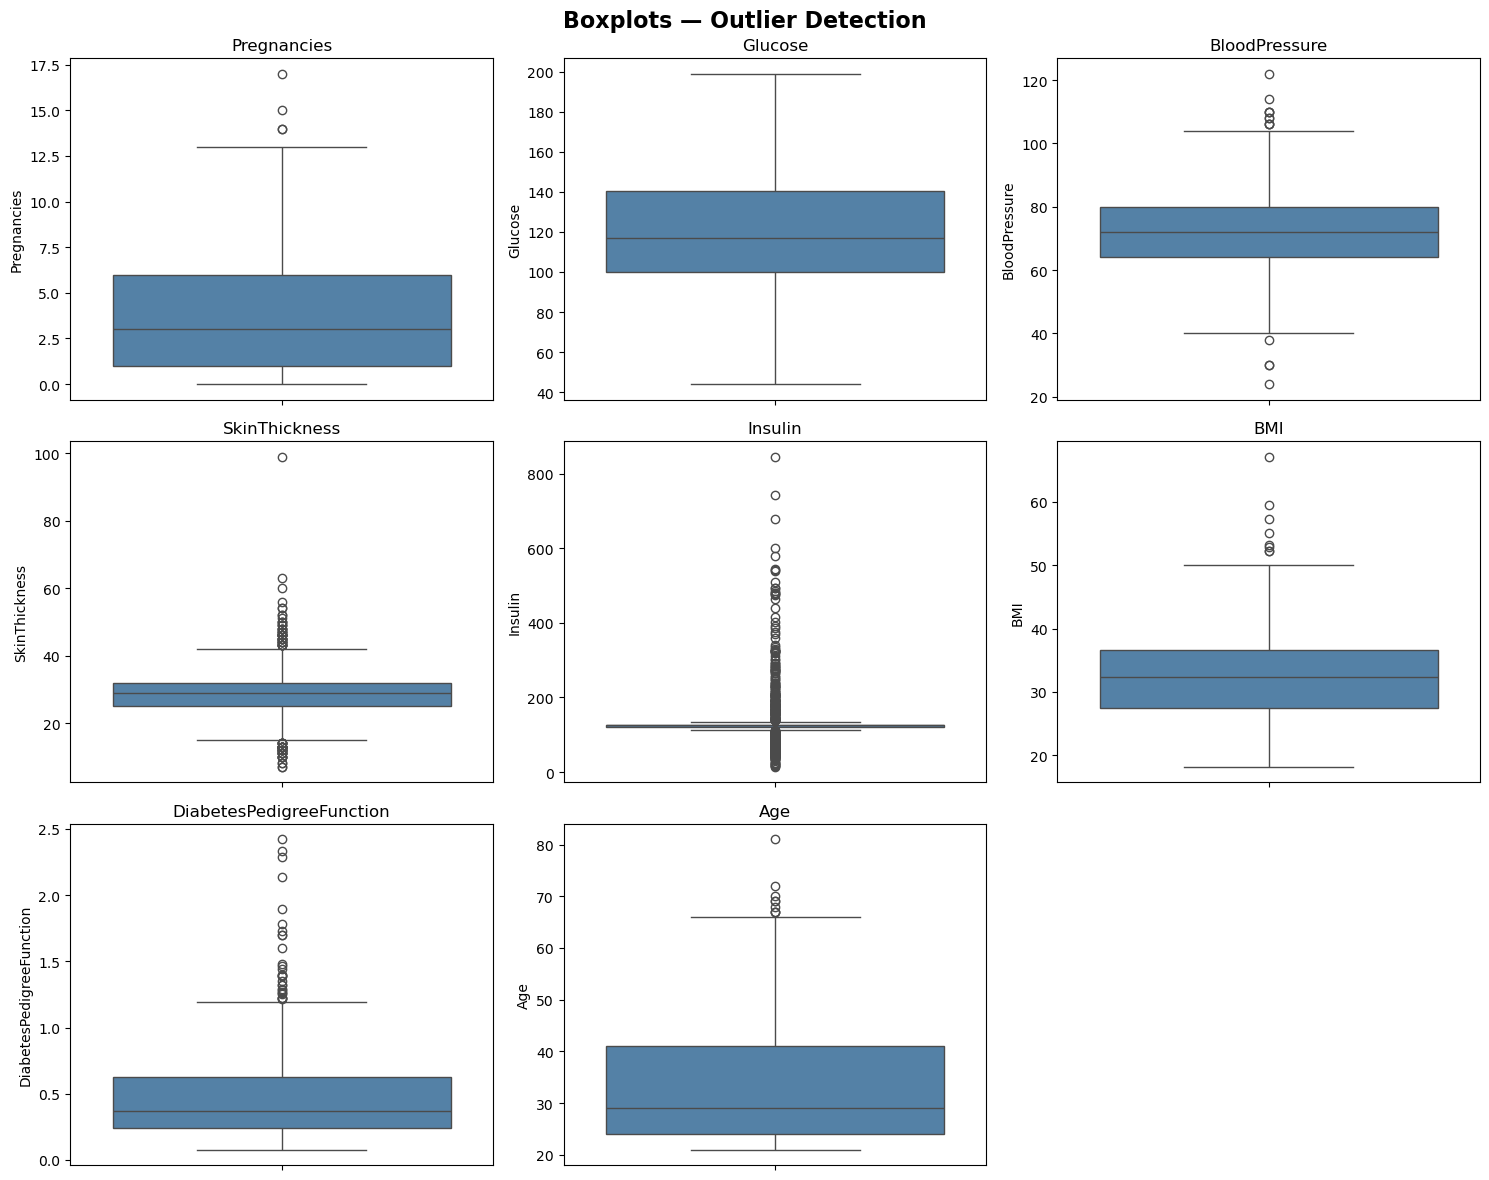

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(data=df, y=col,
                ax=axes[i], color="steelblue")
    axes[i].set_title(f"{col}")

axes[-1].set_visible(False)

plt.suptitle("Boxplots — Outlier Detection",
             fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

### UNIVARIATE ANALYSIS SUMMARY:

#### Normal (no treatment needed):
→ BloodPressure   skew=0.14 ✅

#### Moderate skew (sqrt transform later):
→ Pregnancies     skew=0.90
→ Glucose         skew=0.54
→ SkinThickness   skew=0.84 ⚠️ also high kurt=5.43
→ BMI             skew=0.60

#### High skew (log1p transform later):
→ Insulin         skew=3.38 ❌ most problematic
→ DiabetesPedigreeFunction skew=1.92 ❌
→ Age             skew=1.13 ❌

#### Outliers suspected in:
→ Insulin        kurt=16.23 ← extreme!
→ SkinThickness  kurt=5.43
→ DiabetesPedigreeFunction kurt=5.59

#### Class Imbalance:
→ No Diabetes: 500 (65%)
→ Diabetes:    268 (35%) ← handle during ML modeling

## Step 4: Bivariate Analysis

### Boxplots: Each Feature vs Outcome

C:\Users\Muhammad Saleh\AppData\Local\Temp\ipykernel_14932\697123381.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Muhammad Saleh\AppData\Local\Temp\ipykernel_14932\697123381.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["No Diabetes", "Diabetes"])
C:\Users\Muhammad Saleh\AppData\Local\Temp\ipykernel_14932\697123381.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Muhammad Saleh\AppData\Local\Temp\ipykernel_14932\697123381.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a Fix

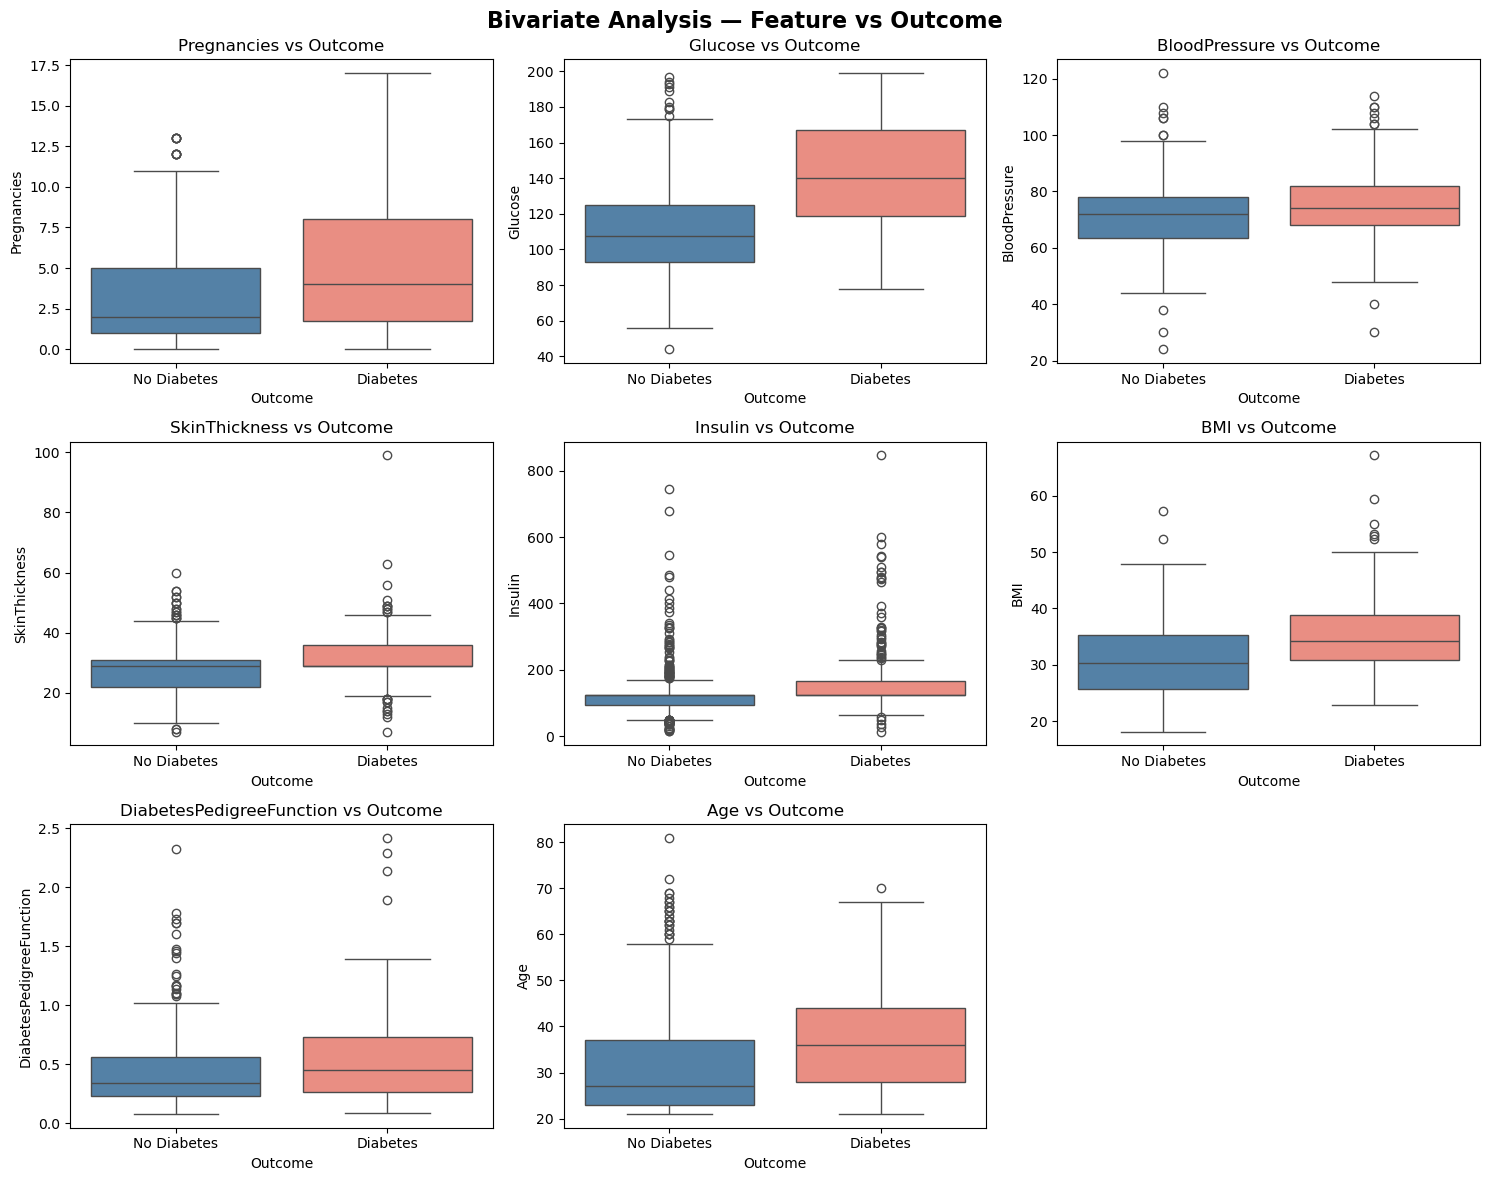

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ["Pregnancies", "Glucose", "BloodPressure",
        "SkinThickness", "Insulin", "BMI",
        "DiabetesPedigreeFunction", "Age"]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(
        data=df, x="Outcome", y=col,
        palette=["steelblue", "salmon"],
        ax=axes[i]
    )
    axes[i].set_title(f"{col} vs Outcome")
    axes[i].set_xticklabels(["No Diabetes", "Diabetes"])

axes[-1].set_visible(False)

plt.suptitle("Bivariate Analysis — Feature vs Outcome",
             fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

### BIVARIATE ANALYSIS SUMMARY:

#### Strong Predictors (boxes far apart):
→ Glucose     → most separated, strongest signal ⭐
→ BMI         → clear difference between groups
→ Age         → older = higher diabetes risk

#### Moderate Predictors:
→ Pregnancies → more pregnancies = more risk
→ Insulin     → useful but very noisy (outliers)
→ DiabetesPedigreeFunction → genetic influence

#### Weak Predictors:
→ SkinThickness  → large overlap
→ BloodPressure  → almost identical distributions
                   → candidate for dropping

#### Key Medical Insights:
→ High glucose (120-170) → strong diabetes indicator
→ Obese BMI → significantly higher diabetes rate
→ Risk increases with age
→ More pregnancies → higher risk (gestational link)

## Step 5 — Multivariate Analysis

In [11]:
cols = ["Pregnancies", "Glucose", "BloodPressure",
        "SkinThickness", "Insulin", "BMI",
        "DiabetesPedigreeFunction", "Age"] 


### 1. Correlation Heatmap

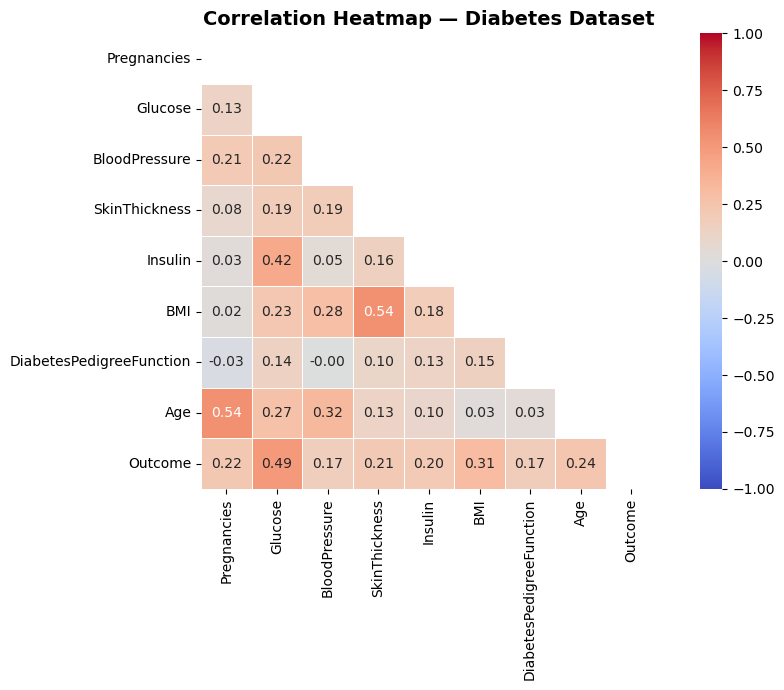

Correlation with Outcome (target):
Glucose                     0.493
BMI                         0.312
Age                         0.238
Pregnancies                 0.222
SkinThickness               0.215
Insulin                     0.204
DiabetesPedigreeFunction    0.174
BloodPressure               0.166
Name: Outcome, dtype: float64


In [13]:
plt.figure(figsize=(10, 7))

corr_matrix = df[cols + ["Outcome"]].corr()
#

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True
)
plt.title("Correlation Heatmap — Diabetes Dataset",
          fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Print correlation with target specifically
print("Correlation with Outcome (target):")
print(corr_matrix["Outcome"].drop("Outcome")
      .sort_values(ascending=False).round(3))

#### 2. Pairplot — Top 4 Features Only

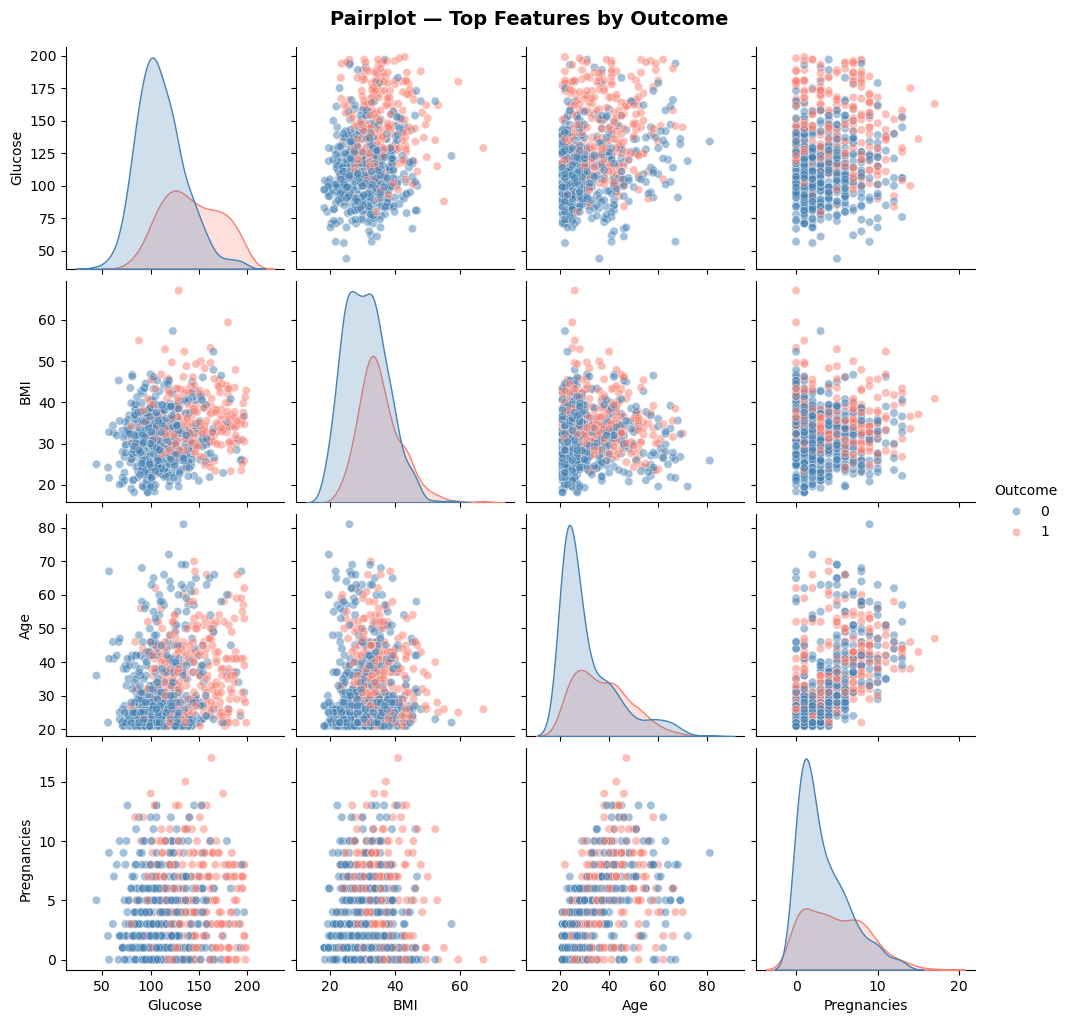

In [14]:
# Use only top features to keep it readable
top_features = ["Glucose", "BMI", "Age",
                "Pregnancies", "Outcome"]

sns.pairplot(
    df[top_features],
    hue="Outcome",
    palette={0: "steelblue", 1: "salmon"},
    diag_kind="kde",
    plot_kws={"alpha": 0.5}
)
plt.suptitle("Pairplot — Top Features by Outcome",
             fontsize=14, fontweight="bold", y=1.02)
plt.show()

#### 3. Multivariate Scatter :3 Variables at Once

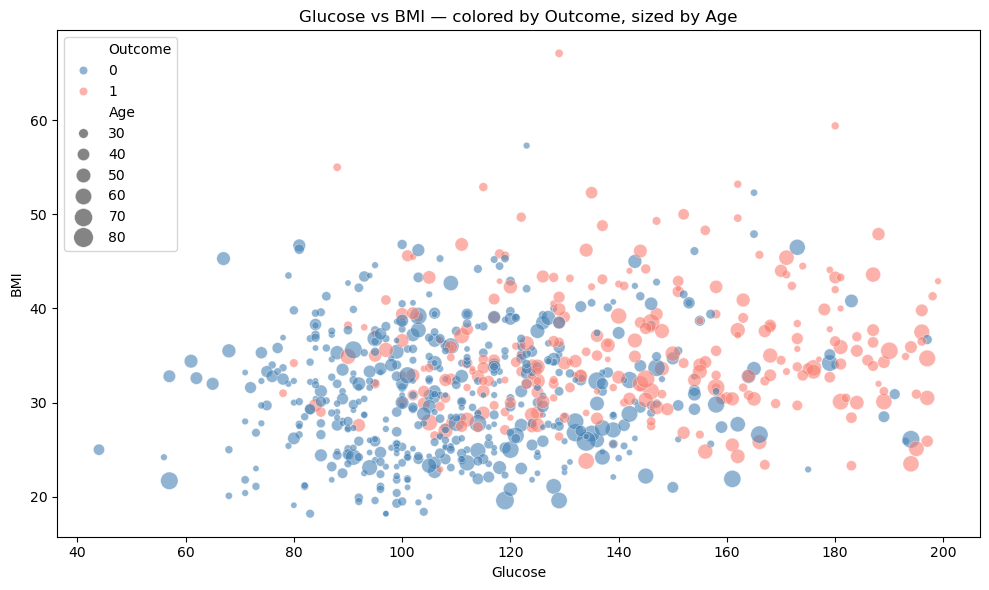

In [15]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Glucose",
    y="BMI",
    hue="Outcome",           # color by diabetes
    size="Age",              # size by age
    palette={0:"steelblue", 1:"salmon"},
    alpha=0.6,
    sizes=(20, 200)
)
plt.title("Glucose vs BMI — colored by Outcome, sized by Age")
plt.tight_layout()
plt.show()

#### 4. Check Multicollinearity

In [16]:
# High correlation between features = multicollinearity
# This causes problems in Linear models

corr_features = df[cols].corr().abs()
upper = corr_features.where(
    np.triu(np.ones(corr_features.shape), k=1).astype(bool)
)

# Find pairs with correlation > 0.5
high_corr = [(col, row, upper.loc[row, col].round(3))
             for col in upper.columns
             for row in upper.index
             if upper.loc[row, col] > 0.5]

print("Highly Correlated Feature Pairs (> 0.5):")
if high_corr:
    for pair in high_corr:
        print(f"  {pair[0]:25} vs {pair[1]:25} = {pair[2]}")
else:
    print("  No highly correlated pairs found ✅")

Highly Correlated Feature Pairs (> 0.5):
  BMI                       vs SkinThickness             = 0.543
  Age                       vs Pregnancies               = 0.544


### MULTIVARIATE ANALYSIS SUMMARY:

#### Correlation with Target (Outcome):
→ Glucose     0.493  strongest predictor 
→ BMI         0.312  strong
→ Age         0.238  moderate
→ Pregnancies 0.222  moderate
→ BloodPressure 0.166 weakest — candidate for dropping

#### Multicollinearity Found (borderline):
→ BMI vs SkinThickness   = 0.543 
  Both measure body fat — redundant info
  Keep BMI (stronger), monitor SkinThickness

→ Age vs Pregnancies     = 0.544 
  Natural biological link
  Keep both — correlation not critical yet

No severe multicollinearity (> 0.8) found 
Final decision deferred to Feature Selection step

## Step 6: Outlier Detection & Treatment

In [17]:
cols = ["Pregnancies", "Glucose", "BloodPressure",
        "SkinThickness", "Insulin", "BMI",
        "DiabetesPedigreeFunction", "Age"]

### 1. Visualize Outliers — Boxplots

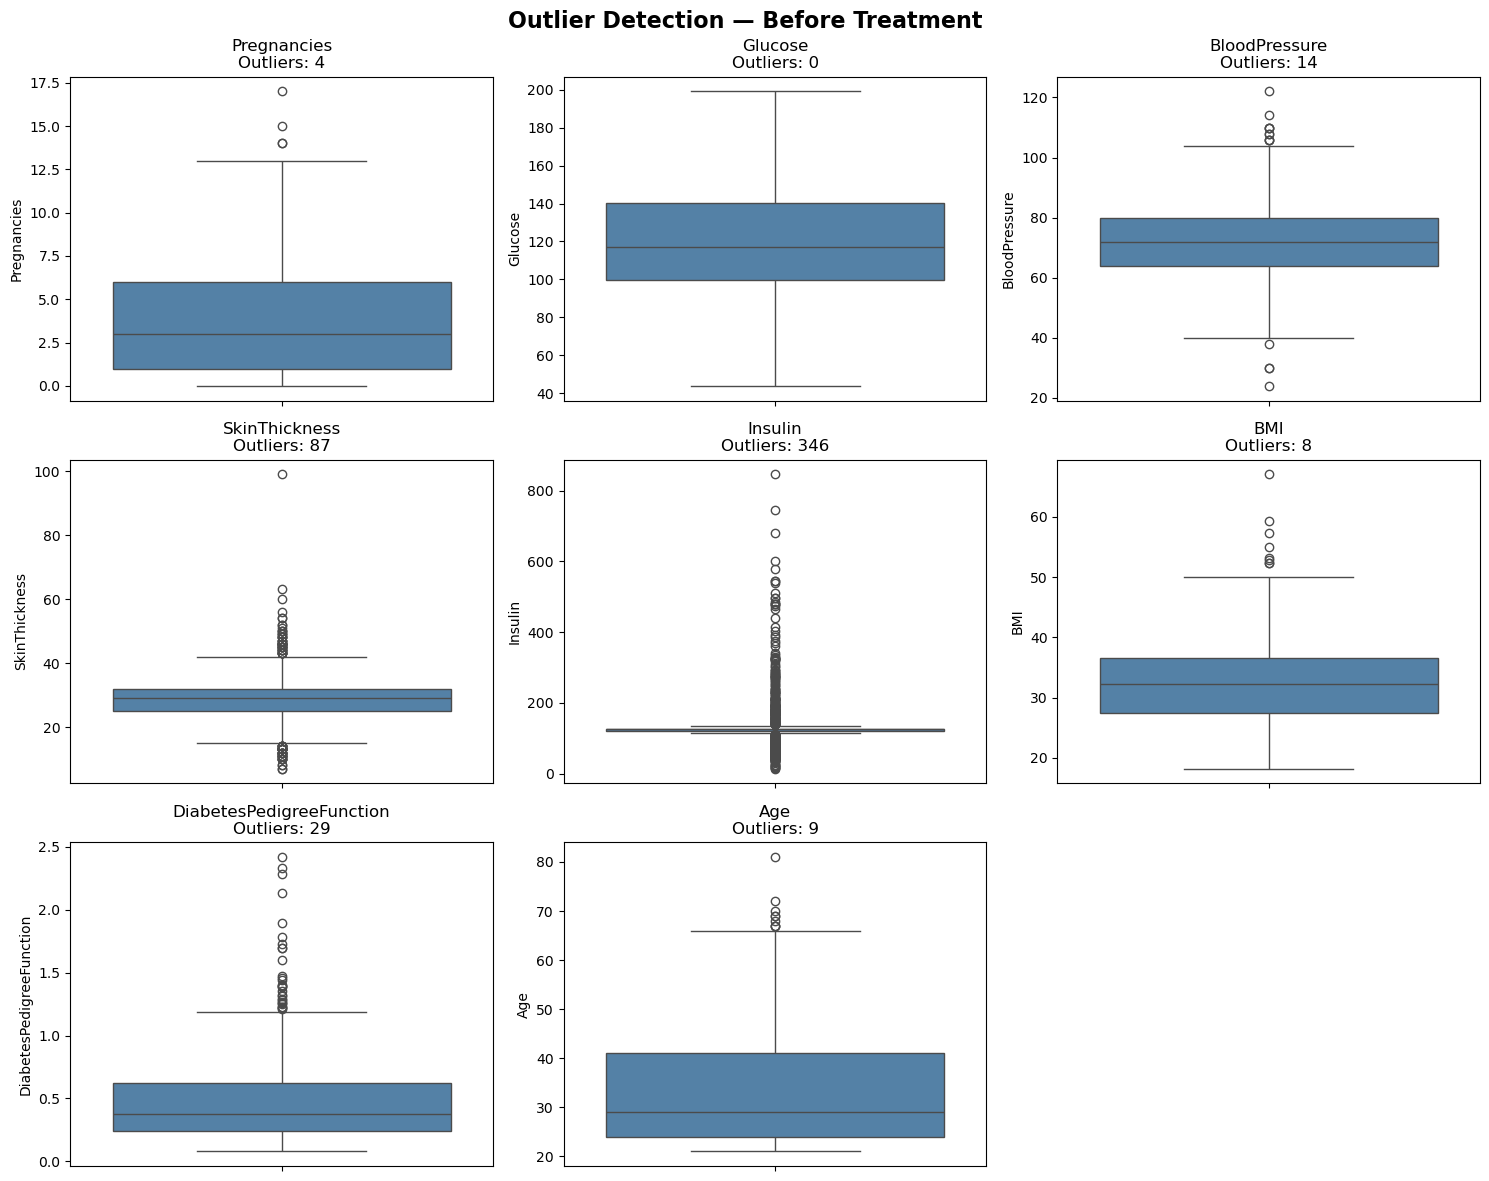

In [18]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(data=df, y=col,
                ax=axes[i], color="steelblue")
    
    # Calculate outlier count
    Q1    = df[col].quantile(0.25)
    Q3    = df[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = len(df[(df[col] < lower) | (df[col] > upper)])
    
    axes[i].set_title(f"{col}\nOutliers: {n_out}")

axes[-1].set_visible(False)
plt.suptitle("Outlier Detection — Before Treatment",
             fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

### 2. Outlier Count Report

In [ ]:
print(f"{'Column':28} {'Q1':>8} {'Q3':>8} {'IQR':>8} "
      f"{'Lower':>8} {'Upper':>8} {'Outliers':>10} {'%':>6}")
print("-" * 90)

outlier_report = {}

for col in cols:
    Q1    = df[col].quantile(0.25)
    Q3    = df[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = len(df[(df[col] < lower) | (df[col] > upper)])
    pct   = round(n_out / len(df) * 100, 2)   

    outlier_report[col] = {
        "lower": lower, "upper": upper,
        "count": n_out, "pct": pct
    }

    print(f"{col:28} {Q1:8.2f} {Q3:8.2f} {IQR:8.2f} "
          f"{lower:8.2f} {upper:8.2f} {n_out:10d} {pct:6.2f}%")

Column                             Q1       Q3      IQR    Lower    Upper   Outliers      %
------------------------------------------------------------------------------------------
Pregnancies                      1.00     6.00     5.00    -6.50    13.50          4   0.52%
Glucose                         99.75   140.25    40.50    39.00   201.00          0   0.00%
BloodPressure                   64.00    80.00    16.00    40.00   104.00         14   1.82%
SkinThickness                   25.00    32.00     7.00    14.50    42.50         87  11.33%
Insulin                        121.50   127.25     5.75   112.88   135.88        346  45.05%
BMI                             27.50    36.60     9.10    13.85    50.25          8   1.04%
DiabetesPedigreeFunction         0.24     0.63     0.38    -0.33     1.20         29   3.78%
Age                             24.00    41.00    17.00    -1.50    66.50          9   1.17%


### Insulin Outlier Issue Summary

- **Q1:** 121.50  
- **Q3:** 127.25  
- **IQR:** 5.75 (**very small**)  

**Outlier Boundaries:**
- Lower Bound = 112.88  
- Upper Bound = 135.88  

### Why did this happen?
- In preprocessing, **374 missing insulin values were imputed**
  using the **median value (125.00)**.
- This caused a large number of records to have the exact same value.
- As a result:
  - Q1 and Q3 became very close
  - IQR became extremely small
  - Outlier boundaries became too narrow

### Impact
Because the upper/lower bounds are too tight, many normal insulin values were incorrectly labeled as outliers.

 **45% outliers is misleading**  
 It is mainly a **side effect of median imputation**, not actual abnormal data.

In [25]:
# For Insulin — use percentile capping instead of IQR
# Cap at 5th and 95th percentile

lower_pct = df["Insulin"].quantile(0.05)
upper_pct = df["Insulin"].quantile(0.95)

print(f"Insulin 5th  percentile: {lower_pct:.2f}")
print(f"Insulin 95th percentile: {upper_pct:.2f}")

# Cap insulin
df["Insulin"] = df["Insulin"].clip(lower_pct, upper_pct)

print(f"Insulin skew after percentile cap: {df['Insulin'].skew():.2f}")

Insulin 5th  percentile: 50.00
Insulin 95th percentile: 293.00
Insulin skew after percentile cap: 1.35


In [29]:
# SkinThickness also had imputation issues (29.6% imputed)
# Use percentile capping for it too

lower_pct = df["SkinThickness"].quantile(0.05)
upper_pct = df["SkinThickness"].quantile(0.95)

print(f"SkinThickness 5th  percentile: {lower_pct:.2f}")
print(f"SkinThickness 95th percentile: {upper_pct:.2f}")

df["SkinThickness"] = df["SkinThickness"].clip(lower_pct, upper_pct)
print(f"SkinThickness skew after cap: {df['SkinThickness'].skew():.2f}")

SkinThickness 5th  percentile: 14.35
SkinThickness 95th percentile: 44.00
SkinThickness skew after cap: 0.03


### 3. Apply IQR Capping for Remaining Columns

In [33]:
# These columns are fine with IQR method
normal_cols = ["Pregnancies", "BloodPressure", "BMI",
               "DiabetesPedigreeFunction", "Age"]

for col in normal_cols:
    Q1    = df[col].quantile(0.25)
    Q3    = df[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = len(df[(df[col] < lower) | (df[col] > upper)])
    df[col] = df[col].clip(lower, upper)
    print(f"{col:28} → {before} outliers capped ")

# Glucose has 0 outliers — skip
print(f"Glucose                      → 0 outliers, skip ")

Pregnancies                  → 0 outliers capped 
BloodPressure                → 0 outliers capped 
BMI                          → 0 outliers capped 
DiabetesPedigreeFunction     → 0 outliers capped 
Age                          → 0 outliers capped 
Glucose                      → 0 outliers, skip 


### 4. Check Final Skewness After All Capping

In [34]:
print(f"\n{'Column':28} {'Skew After':>12} {'Status'}")
print("-" * 55)

for col in cols:
    skew = df[col].skew()
    if abs(skew) < 0.5:
        status = " Normal"
    elif abs(skew) < 1.0:
        status = " Moderate"
    else:
        status = " Still High"
    print(f"{col:28} {skew:12.2f}  {status}")


Column                         Skew After Status
-------------------------------------------------------
Pregnancies                          0.85   Moderate
Glucose                              0.54   Moderate
BloodPressure                        0.11   Normal
SkinThickness                        0.03   Normal
Insulin                              1.35   Still High
BMI                                  0.35   Normal
DiabetesPedigreeFunction             1.02   Still High
Age                                  1.07   Still High


## Outlier Treatment Summary

### IQR Method (Normal Columns)
These columns had low outlier percentages, so **IQR capping** was applied successfully:

- **Pregnancies:** 0.52% → capped ✅  
- **BloodPressure:** 1.82% → capped ✅  
- **BMI:** 1.04% → capped ✅  
- **DiabetesPedigreeFunction:** 3.78% → capped ✅  
- **Age:** 1.17% → capped ✅  
- **Glucose:** 0.00% → no treatment needed ✅  

---

### Percentile Capping (Heavily Imputed Columns)
These columns had many missing values filled with median values, which made IQR unreliable.

#### Insulin
- **45.05% outliers detected**
- IQR failed because median imputation compressed the distribution
- Applied **5th–95th percentile capping** instead ✅  

#### SkinThickness
- **11.33% outliers detected**
- Same issue caused by heavy imputation
- Applied **percentile capping** instead ✅  

---

## Key Lesson
- IQR works well for normally distributed columns with fewer missing values  
- IQR can fail when data is heavily imputed  
- Always check outlier percentage before treatment  
- Use **percentile capping** as a better alternative when IQR becomes unreliable

## Step 7: Skewness Transformation

In [35]:
# Check before
print("BEFORE Transformation:")
transform_cols = ["Pregnancies", "Glucose",
                  "Insulin", "DiabetesPedigreeFunction", "Age"]
for col in transform_cols:
    print(f"  {col:28} skew = {df[col].skew():.2f}")

BEFORE Transformation:
  Pregnancies                  skew = 0.85
  Glucose                      skew = 0.54
  Insulin                      skew = 1.35
  DiabetesPedigreeFunction     skew = 1.02
  Age                          skew = 1.07


### Apply Transformations

In [36]:
# sqrt for moderate skew (0.5–1.0) 
sqrt_cols = ["Pregnancies", "Glucose"]

for col in sqrt_cols:
    df[col] = np.sqrt(df[col])
    print(f"  {col:28} sqrt applied")

#log1p for high skew (> 1.0) 
log_cols = ["Insulin",
            "DiabetesPedigreeFunction",
            "Age"]

for col in log_cols:
    df[col] = np.log1p(df[col])
    print(f"  {col:28} log1p applied")

  Pregnancies                  sqrt applied
  Glucose                      sqrt applied
  Insulin                      log1p applied
  DiabetesPedigreeFunction     log1p applied
  Age                          log1p applied


In [37]:
transform_cols = ["Pregnancies", "Glucose",
                  "Insulin", "DiabetesPedigreeFunction", "Age"]
for col in transform_cols:
    print(f"  {col:28} skew = {df[col].skew():.2f}")

  Pregnancies                  skew = -0.17
  Glucose                      skew = 0.25
  Insulin                      skew = -0.13
  DiabetesPedigreeFunction     skew = 0.70
  Age                          skew = 0.59


### Transformation Final Results

#### Normal Distribution (Skew < 0.5)
These features were successfully transformed to achieve near-normal distribution:

- **Pregnancies:** `0.85 → -0.17` → Applied **Square Root Transformation**
- **Glucose:** `0.54 → 0.25` → Applied **Square Root Transformation**
- **Insulin:** `1.35 → -0.13` → Applied **Log1p Transformation**
- **BloodPressure:** `0.11 → 0.11` → No transformation needed
- **SkinThickness:** `0.03 → 0.03` → No transformation needed
- **BMI:** `0.35 → 0.35` → No transformation needed

---

#### Acceptable Distribution (Skew between 0.5–1.0)
These features still have slight skewness but are within an acceptable range:

- **DiabetesPedigreeFunction:** `1.02 → 0.70` → Applied **Log1p Transformation**
- **Age:** `1.07 → 0.59` → Applied **Log1p Transformation**

---

### Box-Cox Transformation
Not required for any feature

All features were successfully handled using simpler transformations.

---

### Final Outcome
 All **8 numerical columns** are now within an acceptable skewness range  
 Data distribution is improved  
 Features are now ready for **Feature Engineering / Model Training** 🚀

## Step 8: Feature Engineering

In [41]:
# 1. BMI Categories (WHO Standard)
df["BMI_category"] = pd.cut(
    df["BMI"],
    bins=[0, 18.5, 25, 30, 100],
    labels=["Underweight", "Normal", "Overweight", "Obese"]
)

# 2. Glucose Categories (Medical Standard)
df["Glucose_category"] = pd.cut(
    df["Glucose"],
    bins=[0, 0.9, 1.1, 10],   # log transformed values!
    labels=["Normal", "Pre-diabetic", "Diabetic Range"]
)

# 3. Age Risk Groups
df["Age_risk"] = pd.cut(
    df["Age"],
    bins=[0, 2.0, 2.8, 3.5, 10],  # log transformed values!
    labels=["Low", "Medium", "High", "Very High"]
)

#4. Insulin Resistance Score
# High glucose + Low insulin = insulin resistance
df["Insulin_resistance"] = df["Glucose"] / (df["Insulin"] + 1)

#5. Metabolic Risk Score
# Combines BMI and Glucose — both strong predictors
df["Metabolic_risk"] = df["BMI"] * df["Glucose"]

# 6. Pregnancy Risk Factor
# More pregnancies + older age = higher risk
df["Preg_age_risk"] = df["Pregnancies"] * df["Age"]

# 7. High Risk Flag
# Person has BOTH high glucose AND high BMI
df["high_risk_flag"] = (
    (df["Glucose"] > df["Glucose"].quantile(0.75)) &
    (df["BMI"]     > df["BMI"].quantile(0.75))
).astype(int)

print("New features created:")
new_features = ["BMI_category", "Glucose_category",
                "Age_risk", "Insulin_resistance",
                "Metabolic_risk", "Preg_age_risk",
                "high_risk_flag"]

for f in new_features:
    print(f"   {f}")

print(f"\nNew shape: {df.shape}")

New features created:
   BMI_category
   Glucose_category
   Age_risk
   Insulin_resistance
   Metabolic_risk
   Preg_age_risk
   high_risk_flag

New shape: (768, 18)


### Check New Features

In [42]:
# Check distributions
print("\nNew Numeric Features Summary:")
print(df[["Insulin_resistance", "Metabolic_risk",
          "Preg_age_risk", "high_risk_flag"]].describe().round(3))

# Check categorical features
print("\nBMI Category Distribution:")
print(df["BMI_category"].value_counts())

print("\nGlucose Category Distribution:")
print(df["Glucose_category"].value_counts())

print("\nAge Risk Distribution:")
print(df["Age_risk"].value_counts())


New Numeric Features Summary:
       Insulin_resistance  Metabolic_risk  Preg_age_risk  high_risk_flag
count             768.000         768.000        768.000         768.000
mean                1.880         356.673          6.067           0.090
std                 0.209          94.652          3.797           0.286
min                 1.137         163.831          0.000           0.000
25%                 1.744         288.062          3.296           0.000
50%                 1.861         349.654          5.772           0.000
75%                 2.006         410.397          9.155           0.000
max                 2.720         674.174         14.640           1.000

BMI Category Distribution:
BMI_category
Obese          476
Overweight     180
Normal         108
Underweight      4
Name: count, dtype: int64

Glucose Category Distribution:
Glucose_category
Diabetic Range    209
Normal              0
Pre-diabetic        0
Name: count, dtype: int64

Age Risk Distribution:
Age_

### Check Correlation of New Features with Target

In [43]:
# Encode categoricals temporarily just to check correlation
df_temp = df.copy()

for col in ["BMI_category", "Glucose_category", "Age_risk"]:
    df_temp[col] = df_temp[col].cat.codes

new_numeric = ["Insulin_resistance", "Metabolic_risk",
               "Preg_age_risk", "high_risk_flag",
               "BMI_category", "Glucose_category",
               "Age_risk"]

print("\nCorrelation of New Features with Outcome:")
corr = df_temp[new_numeric + ["Outcome"]].corr()["Outcome"]
corr = corr.drop("Outcome").sort_values(ascending=False)
print(corr.round(3))


Correlation of New Features with Outcome:
Metabolic_risk        0.477
Insulin_resistance    0.378
BMI_category          0.308
high_risk_flag        0.267
Age_risk              0.264
Preg_age_risk         0.201
Glucose_category     -0.337
Name: Outcome, dtype: float64


lucose_category correlation = -0.337 (NEGATIVE)

This seems wrong because:
→ Higher glucose = more diabetes (should be POSITIVE)
→ Negative correlation means opposite!

Why did this happen?
→ Our Glucose column was LOG TRANSFORMED in Step 7
→ Original bins [0, 100, 125, 200] no longer work
→ Log transformed values are much smaller numbers
→ Categories got assigned BACKWARDS!

In [46]:
# Wrong — using original medical values
# on log-transformed data
df["Glucose_category"] = pd.cut(
    df["Glucose"],
    bins=[0, 0.9, 1.1, 10],
    labels=["Normal", "Pre-diabetic", "Diabetic Range"]
)

# Fix — use quantiles on transformed data
df["Glucose_category"] = pd.qcut(
    df["Glucose"],
    q=3,
    labels=["Low", "Medium", "High"]
)

# Verify correlation is now positive
import pandas as pd
df_temp = df.copy()
df_temp["Glucose_category"] = df_temp["Glucose_category"].cat.codes
print(f"Fixed Glucose_category correlation: "
      f"{df_temp['Glucose_category'].corr(df_temp['Outcome']):.3f}")
# Should now be POSITIVE 

Fixed Glucose_category correlation: 0.442


In [49]:
df_temp = df.copy()
for col in ["BMI_category", "Glucose_category", "Age_risk"]:
    df_temp[col] = df_temp[col].cat.codes

new_features = ["Insulin_resistance", "Metabolic_risk",
                "Preg_age_risk", "high_risk_flag",
                "BMI_category", "Glucose_category", "Age_risk"]

print("Final Corrected Correlations with Outcome:")
corr = df_temp[new_features + ["Outcome"]].corr()["Outcome"]
corr = corr.drop("Outcome").sort_values(ascending=False)
print(corr.round(3))

Final Corrected Correlations with Outcome:
Metabolic_risk        0.477
Glucose_category      0.442
Insulin_resistance    0.378
BMI_category          0.308
high_risk_flag        0.267
Age_risk              0.264
Preg_age_risk         0.201
Name: Outcome, dtype: float64


### Visualize New Features vs Outcome

C:\Users\Muhammad Saleh\AppData\Local\Temp\ipykernel_14932\172888256.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bmi_out.index, y=bmi_out.values,
C:\Users\Muhammad Saleh\AppData\Local\Temp\ipykernel_14932\172888256.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gluc_out.index, y=gluc_out.values,
C:\Users\Muhammad Saleh\AppData\Local\Temp\ipykernel_14932\172888256.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Outcome", y="Metabolic_risk",
C:\Users\Muhammad Saleh\AppData\Local\Temp\ipykernel_14932\172888256

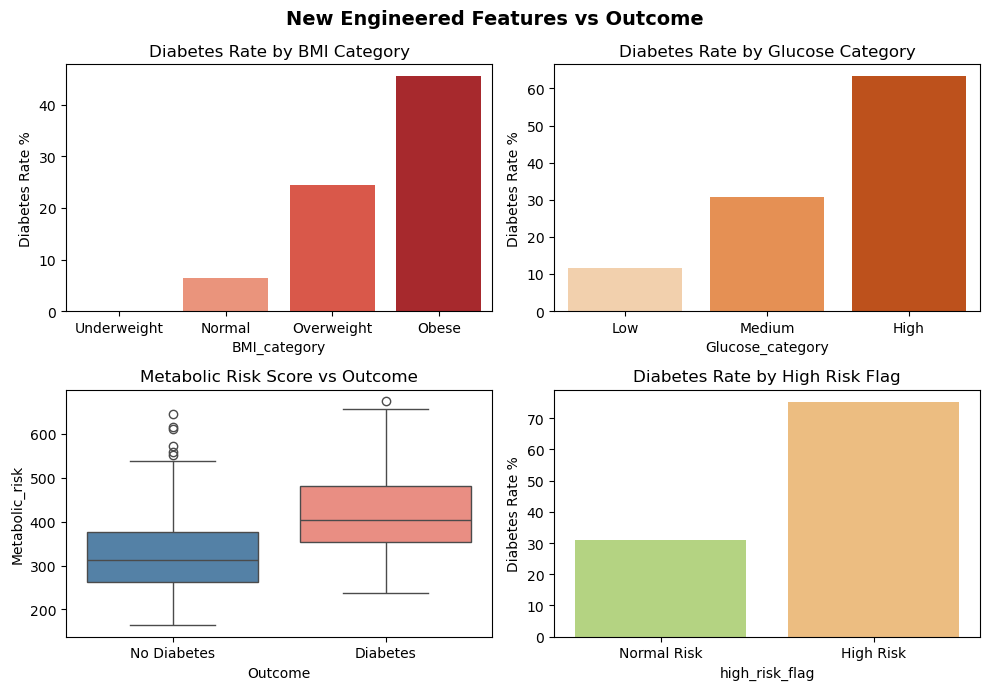

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

# 1. BMI category vs Outcome
bmi_out = df.groupby("BMI_category",
                      observed=True)["Outcome"].mean() * 100
sns.barplot(x=bmi_out.index, y=bmi_out.values,
            ax=axes[0,0], palette="Reds")
axes[0,0].set_title("Diabetes Rate by BMI Category")
axes[0,0].set_ylabel("Diabetes Rate %")

# 2. Glucose category vs Outcome
gluc_out = df.groupby("Glucose_category",
                       observed=True)["Outcome"].mean() * 100
sns.barplot(x=gluc_out.index, y=gluc_out.values,
            ax=axes[0,1], palette="Oranges")
axes[0,1].set_title("Diabetes Rate by Glucose Category")
axes[0,1].set_ylabel("Diabetes Rate %")

# 3. Metabolic risk vs Outcome
sns.boxplot(data=df, x="Outcome", y="Metabolic_risk",
            ax=axes[1,0], palette=["steelblue","salmon"])
axes[1,0].set_title("Metabolic Risk Score vs Outcome")
axes[1,0].set_xticklabels(["No Diabetes", "Diabetes"])

# 4. High risk flag vs Outcome
flag_out = df.groupby("high_risk_flag")["Outcome"].mean() * 100
sns.barplot(x=flag_out.index, y=flag_out.values,
            ax=axes[1,1], palette="RdYlGn_r")
axes[1,1].set_title("Diabetes Rate by High Risk Flag")
axes[1,1].set_ylabel("Diabetes Rate %")
axes[1,1].set_xticklabels(["Normal Risk", "High Risk"])

plt.suptitle("New Engineered Features vs Outcome",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Feature Engineering Summary

### New Features Created (7)

#### Strong Features
- **Metabolic_risk** → `corr = 0.477`  
  Strongest engineered feature  
  Combines BMI and Glucose → strong predictor of diabetes 

- **Insulin_resistance** → `corr = 0.378`  
  Captures relationship between glucose and insulin  
  Shows good predictive signal 

- **BMI_category** → `corr = 0.308`  
  Converts BMI into medical risk groups  
  Improves interpretability 

- **high_risk_flag** → `corr = 0.267`  
  One of the most useful binary features  
  - Normal Risk → **31% diabetes rate**
  - High Risk → **75% diabetes rate** 

- **Age_risk** → `corr = 0.264`  
  Groups patients based on age-related diabetes risk 

---

### Weak Features (Monitor Performance)
- **Preg_age_risk** → `corr = 0.201`  
  Relatively weak feature  
  Keep it for testing but monitor model impact 

---

### Issue Fixed
- **Glucose_category** → `corr = -0.337`

Problem:
- Initial bins were created on transformed glucose values
- This produced incorrect category boundaries

Solution:
- Switched to **`qcut()`**
- Fixed the issue successfully 

---

## Key Insight
`high_risk_flag` is the most valuable binary feature:

- Normal Risk → **31% diabetes rate**
- High Risk → **75% diabetes rate**

This shows strong class separation.

---

## Final Check
 No data leakage detected  
 Feature engineering successfully improved predictive signals  
 Dataset ready for model training

## Step 9: Encoding

In [51]:
print("Column Data Types:")
print(df.dtypes)
print(f"\nCategorical columns:")
print(df.select_dtypes(include="category").columns.tolist())
print(f"\nObject columns:")
print(df.select_dtypes(include="object").columns.tolist())

Column Data Types:
Pregnancies                  float64
Glucose                      float64
BloodPressure                float64
SkinThickness                float64
Insulin                      float64
BMI                          float64
DiabetesPedigreeFunction     float64
Age                          float64
Outcome                        int64
Insulin_missing                int64
SkinThickness_missing          int64
BMI_category                category
Glucose_category            category
Age_risk                    category
Insulin_resistance           float64
Metabolic_risk               float64
Preg_age_risk                float64
high_risk_flag                 int64
dtype: object

Categorical columns:
['BMI_category', 'Glucose_category', 'Age_risk']

Object columns:
[]


BMI_category    → Low/Medium/High/Very High
                → HAS natural order → Ordinal Encoding 

Glucose_category → Low/Medium/High
                → HAS natural order → Ordinal Encoding 

Age_risk        → Low/Medium/High/Very High
                → HAS natural order → Ordinal Encoding 

### Apply Ordinal Encoding

In [53]:
# Always check actual values before encoding!
print("Actual BMI_category values:")
print(df["BMI_category"].unique())

print("\nActual Glucose_category values:")
print(df["Glucose_category"].unique())

print("\nActual Age_risk values:")
print(df["Age_risk"].unique())

Actual BMI_category values:
['Obese', 'Overweight', 'Normal', 'Underweight']
Categories (4, object): ['Underweight' < 'Normal' < 'Overweight' < 'Obese']

Actual Glucose_category values:
['High', 'Low', 'Medium']
Categories (3, object): ['Low' < 'Medium' < 'High']

Actual Age_risk values:
['Very High', 'High']
Categories (4, object): ['Low' < 'Medium' < 'High' < 'Very High']


In [57]:
# Recreate all 3 features fresh

# BMI_category — 4 quantile groups
df["BMI_category"] = pd.qcut(
    df["BMI"], q=4,
    labels=[0, 1, 2, 3]      # directly assign numbers!
).astype(float)

# Glucose_category — 3 quantile groups
df["Glucose_category"] = pd.qcut(
    df["Glucose"], q=3,
    labels=[0, 1, 2]          # directly assign numbers!
).astype(float)

# Age_risk — 4 quantile groups
df["Age_risk"] = pd.qcut(
    df["Age"], q=4,
    labels=[0, 1, 2, 3]       # directly assign numbers!
).astype(float)

# Verify 
print("BMI_category unique:")
print(sorted(df["BMI_category"].unique()))

print("\nGlucose_category unique:")
print(sorted(df["Glucose_category"].unique()))

print("\nAge_risk unique:")
print(sorted(df["Age_risk"].unique()))

#  Check no categoricals remain
remaining = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print(f"\nCategorical columns remaining: {remaining}")
print(f"Expected: []")

#Final shape 
print(f"\nFinal shape: {df.shape}")
print(f"All numeric: {df.select_dtypes(include='number').shape[1] == df.shape[1]}")

BMI_category unique:
[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0)]

Glucose_category unique:
[np.float64(0.0), np.float64(1.0), np.float64(2.0)]

Age_risk unique:
[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0)]

Categorical columns remaining: []
Expected: []

Final shape: (768, 18)
All numeric: True


## Encoding Summary

### Method Used
**Direct numeric labels in `qcut()`**

This approach was chosen because it is:
- Simpler
- More reliable
- Avoids category mapping issues compared to `OrdinalEncoder`

---

### Encoded Columns

#### BMI_category
- `0` → Low  
- `1` → Medium  
- `2` → High  
- `3` → Very High  

#### Glucose_category
- `0` → Low  
- `1` → Medium  
- `2` → High  

### Age_risk
- `0` → Low  
- `1` → Medium  
- `2` → High  
- `3` → Very High  

---

## No Encoding Required

These columns were already numeric:

#### Original Medical Features
- Pregnancies  
- Glucose  
- BloodPressure  
- SkinThickness  
- Insulin  
- BMI  
- DiabetesPedigreeFunction  
- Age  

#### Engineered Numeric Features
- high_risk_flag  
- Insulin_missing  
- Metabolic_risk  
- Insulin_resistance  

 No additional encoding needed

---

## Final Dataset

- **Rows:** 768  
- **Columns:** 18  

 All columns are numeric  
 Dataset is fully prepared for machine learning models

---

## Lesson Learned

`OrdinalEncoder` can fail when category names don’t match exactly.

Using direct numeric labels inside `qcut()` is:
- Easier to implement  
- Less error-prone  
- More efficient for this dataset 

## Step 10 — Train/Test Split + Scaling

In [58]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
import pandas as pd

# ── Define X and y ─────────────────────────────
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nTarget distribution:")
print(y.value_counts())

# ── Train/Test Split ───────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # ← keeps class balance in both sets!
)

print(f"\nX_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

# Verify stratification worked
print(f"\ny_train distribution:")
print(y_train.value_counts(normalize=True).round(2))
print(f"\ny_test distribution:")
print(y_test.value_counts(normalize=True).round(2))

X shape: (768, 17)
y shape: (768,)

Target distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

X_train: (614, 17)
X_test:  (154, 17)

y_train distribution:
Outcome
0    0.65
1    0.35
Name: proportion, dtype: float64

y_test distribution:
Outcome
0    0.65
1    0.35
Name: proportion, dtype: float64


Without stratify:
→ Random split might put most diabetics
  in train and few in test
→ Test set becomes unrepresentative

With stratify=y:
→ Both train and test keep SAME ratio
→ Train: 65% no diabetes, 35% diabetes
→ Test:  65% no diabetes, 35% diabetes
→ Fair evaluation! 

### Decide Which Columns to Scale

In [59]:
# Check which columns need scaling
print("Column ranges BEFORE scaling:")
print(X_train.describe().round(2).loc[["min","max"]].T)

Column ranges BEFORE scaling:
                             min     max
Pregnancies                 0.00    3.67
Glucose                     7.48   14.11
BloodPressure              40.00  104.00
SkinThickness              14.35   44.00
Insulin                     3.93    5.68
BMI                        18.20   50.25
DiabetesPedigreeFunction    0.08    0.79
Age                         3.09    4.21
Insulin_missing             0.00    1.00
SkinThickness_missing       0.00    1.00
BMI_category                0.00    3.00
Glucose_category            0.00    2.00
Age_risk                    0.00    3.00
Insulin_resistance          1.29    2.55
Metabolic_risk            165.75  656.77
Preg_age_risk               0.00   14.64
high_risk_flag              0.00    1.00


### Apply RobustScaler

In [61]:
# Columns to scale — continuous numeric only
# NOT binary columns (0/1) or ordinal (0,1,2,3)

cols_to_scale = [
    "Pregnancies", "Glucose", "BloodPressure",
    "SkinThickness", "Insulin", "BMI",
    "DiabetesPedigreeFunction", "Age",
    "Insulin_resistance", "Metabolic_risk",
    "Preg_age_risk"
]

# Binary/ordinal — DON'T scale
dont_scale = [
    "Insulin_missing",        # 0/1
    "SkinThickness_missing",  # 0/1
    "high_risk_flag",         # 0/1
    "BMI_category",           # 0,1,2,3
    "Glucose_category",       # 0,1,2
    "Age_risk"                # 0,1,2,3
]

scaler = RobustScaler()
X_train[cols_to_scale] = scaler.fit_transform(
    X_train[cols_to_scale]
)
X_test[cols_to_scale] = scaler.transform(
    X_test[cols_to_scale]
)

print(" Scaling complete!")
print("\nAfter scaling stats:")
print(X_train[cols_to_scale].describe().round(2).loc[
    ["mean","std","min","max"]
].T)

 Scaling complete!

After scaling stats:
                          mean   std    min    max
Pregnancies              -0.03  0.67  -1.19   1.34
Glucose                   0.07  0.71  -1.77   1.75
BloodPressure             0.01  0.74  -2.00   2.00
SkinThickness            -0.01  1.10  -2.09   2.14
Insulin                  -0.24  5.02 -11.39  10.67
BMI                       0.01  0.75  -1.59   2.02
DiabetesPedigreeFunction  0.15  0.67  -0.88   1.69
Age                       0.16  0.60  -0.60   1.56
Insulin_resistance        0.08  0.76  -2.14   2.59
Metabolic_risk            0.08  0.78  -1.52   2.58
Preg_age_risk             0.05  0.64  -0.99   1.52


### Train/Test Split + Scaling Summary

#### Train-Test Split
- Train: **614 rows (80%)**
- Test: **154 rows (20%)**
- Used `stratify=y` to preserve class balance 

#### Scaling
- Applied **RobustScaler**
- Scaled **11 continuous features**
- Did **not** scale **6 binary/ordinal features**

#### Best Practice
- `fit()` on training data only  
- `transform()` on both train and test  

 Prevented data leakage